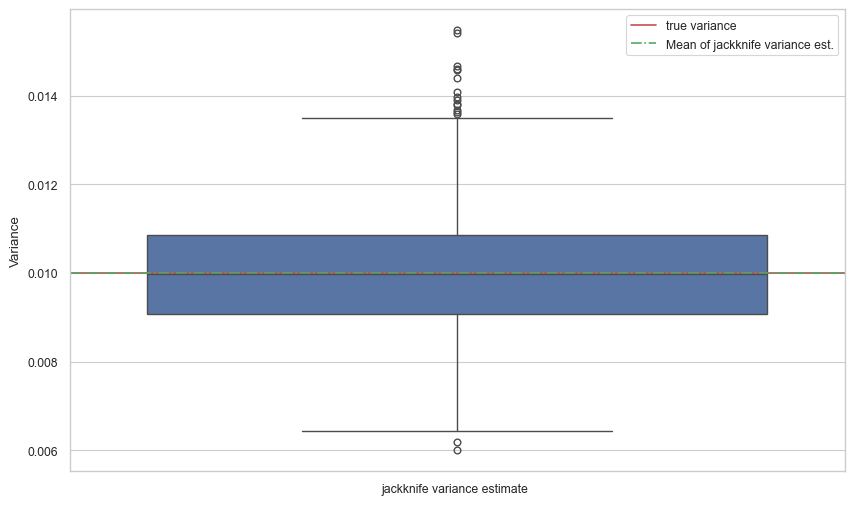

In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
sim_n = 1000  # number of simulations
n = 100       # sample size

# Initialize array to store jackknife variances
se_jackknife_sim = np.zeros(sim_n)

# Set random seed for reproducibility
np.random.seed(42)

# Run simulations
for i in range(sim_n):
    x = np.random.normal(0, 1, n)
    # Jackknife estimate of the variance
    se_jackknife_sim[i] = np.var(x, ddof=1) / n

# Convert the results to a DataFrame for easier handling with Seaborn
df = pd.DataFrame({'jackknife variance estimate ': se_jackknife_sim})

# Plot with Seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(context='paper',style="whitegrid")  # Setting the style to whitegrid
sns.boxplot(data=df)

plt.axhline(y=1/n, color='r', linestyle='-', label='true variance' )  # Add a line for the true variance

plt.axhline(y=df[df.columns[0]].mean(), color='g', linestyle='dashdot', label='Mean of jackknife variance est.')  # Add a line for the true variance
plt.ylabel('Variance')
plt.legend()
plt.savefig("boxplot_JK_linear_estimator_seaborn_grid.png", dpi = 1000)
# dpi anpassen für bessere Qualität

plt.show()


In [34]:
df[df.columns[0]].mean()

0.01000941627764721

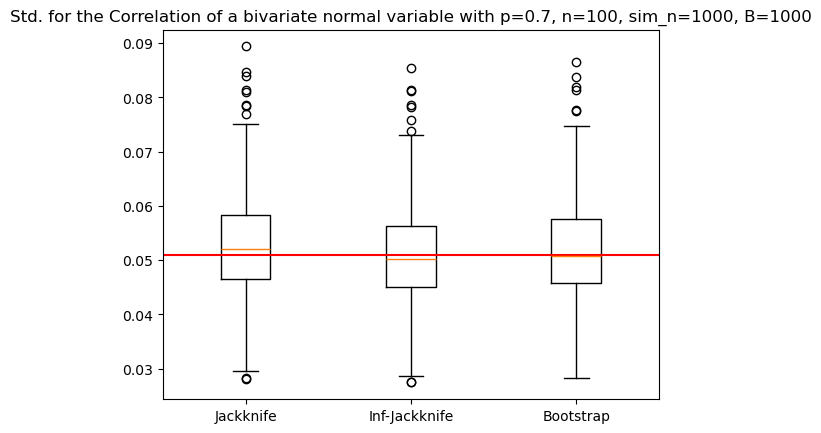

In [5]:
# Definition der Funktionen
def jackknife(x,y, func):
    n = len(x)
    idx = np.arange(n)
    jack_i =  [func(x[idx!=i], y[idx!=i])[0,1] for i in range(n)]
    jack_mean = np.mean(jack_i)
    return np.sqrt(((n-1) / n )*np.sum((jack_i - jack_mean)**2))

def bootstrap(x, y, func, B):
    n = len(x)
    idxs = np.random.choice(np.arange(n), (B, n), replace=True)
    bootstrap = [func(x[idx], y[idx])[0,1] for idx in idxs]
    return np.std(bootstrap, ddof=1)

def mean_weighted(x,p_i):
    return np.sum(x*p_i)

def inf_jack(x,y,func,e):
    n = len(x)
    T_0 = func(x,y)[0,1]
    U_i = np.zeros(len(x))
    for i in range(n):
        weights_inf_jk  = np.full(n, (1 - e) / n)
        weights_inf_jk[i] += e
        mean_x = mean_weighted(x,weights_inf_jk)
        mean_y = mean_weighted(y,weights_inf_jk)
        T_weighted = np.sum(weights_inf_jk*(x-mean_x)*(y-mean_y)) /   np.sqrt( np.sum(weights_inf_jk*(x-mean_x)**2) * np.sum(weights_inf_jk*(y-mean_y)**2) )
        U_i[i] = (T_weighted - T_0 )/e
    return  np.sqrt(np.sum(U_i**2)/n**2)

### Simulation ###

# ZV´s
mean = [0, 0]          
p = 0.7     
cov = [[1,p], [p, 1]] 

sim_n = 1_000  # number of simulations
n = 100        # sample size
B = 1_000      # Bootstrap samples

se_jackknife = np.zeros(sim_n)
se_jackknife_inf = np.zeros(sim_n)
se_bootstrap = np.zeros(sim_n)

np.random.seed(1)
for i in range(sim_n):
    x, y = np.random.multivariate_normal(mean, cov, n).T
    
    se_jackknife[i] = jackknife(x,y, np.corrcoef)
    se_jackknife_inf[i] = inf_jack(x,y, np.corrcoef,0.000000001)
    se_bootstrap[i] = bootstrap(x,y, np.corrcoef,B)
    
# true std for the correlation https://www.jstor.org/stable/pdf/2277400.pdf?refreqid=fastly-default%3Aef46e66363b4ca95a1a81b2e1b6d92f0&ab_segments=&origin=&initiator=&acceptTC=1
true_sd_corr = (1-p**2)/np.sqrt(n)

# plot
plt.boxplot([se_jackknife, se_jackknife_inf, se_bootstrap], labels=['Jackknife','Inf-Jackknife', 'Bootstrap'])
plt.axhline(y=true_sd_corr, color='r', linestyle='-')
plt.title(f'Std. for the Correlation of a bivariate normal variable with p={p}, n={n}, sim_n={sim_n}, B={B}')
plt.savefig(
        "boxplot_JK_nonlinear_estimator.png"
    )
#true_sd_corr